# Live Camera Test — PatchCore Anomaly Detection

Point your **MacBook camera** at a part, snap a photo, and let the trained models say
**GOOD vs DEFECT** — plus a heatmap of *where* the anomaly is.

This notebook **loads the 4 models already trained** in `anomaly_detection_poc.ipynb`
(`models/<part>_patchcore.npy`). It does **not** retrain anything — just run the cells top to bottom.

### ⚠️ Read this first — how to get sensible results
The models learned from the MVTec dataset: **one object, filling the frame, on a plain background,
even lighting.** To match that, when you hold something up to the camera:
- **Fill the frame** with the object (hold it close, roughly centered — the photo is center-cropped).
- Use a **plain, uncluttered background** (a sheet of white paper works well).
- **Even, bright lighting**, no harsh shadows or glare.
- Hold it **steady** for the snapshot.

Because a webcam is a different "domain" than the dataset (different camera, lighting, background),
the **absolute scores run higher than in training**, so the good/defect *threshold* is only a rough
guide. The **heatmap** (where the model sees something unusual) is the most trustworthy output.


## 0. Setup — imports, feature extractor, preprocessing (same as training)

In [11]:
from pathlib import Path
import time

import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
import cv2
import matplotlib.pyplot as plt
from IPython.display import clear_output

from torchvision.models import resnet18, ResNet18_Weights
from torchvision.models.feature_extraction import create_feature_extractor
from torchvision import transforms

ROOT = Path.cwd()
PARTS = ["bottle", "screw", "tile", "toothbrush"]
MODEL_DIR = ROOT / "models"
DEVICE = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")

# --- exact same feature pipeline used to train the models ---
_weights = ResNet18_Weights.IMAGENET1K_V1
_extractor = create_feature_extractor(resnet18(weights=_weights),
                                      return_nodes=["layer2", "layer3"]).eval().to(DEVICE)
for p in _extractor.parameters():
    p.requires_grad_(False)

preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

@torch.no_grad()
def patch_grid(pil_img):
    """One PIL image -> (H, W, C) grid of patch features (same as training)."""
    x = preprocess(pil_img.convert("RGB")).unsqueeze(0).to(DEVICE)
    feats = _extractor(x)
    f2, f3 = feats["layer2"], feats["layer3"]
    f3 = F.interpolate(f3, size=f2.shape[-2:], mode="bilinear", align_corners=False)
    f2 = F.avg_pool2d(f2, 3, 1, 1)
    f3 = F.avg_pool2d(f3, 3, 1, 1)
    emb = torch.cat([f2, f3], dim=1)[0]                 # (C, H, W)
    return emb.permute(1, 2, 0).cpu().numpy()           # (H, W, C)

print("Device:", DEVICE, "| feature extractor ready")

Device: mps | feature extractor ready


## 1. Load the 4 trained models + set a threshold for each

We load each saved memory bank and compute that part's threshold from its own `train/good` images
(99th percentile of good scores) — so this notebook is fully self-contained.

In [12]:
def image_score(bank_t, pil_img, return_map=False):
    """PatchCore score for one image: max over patches of distance to nearest good patch."""
    g = patch_grid(pil_img)
    H, W, C = g.shape
    q = torch.from_numpy(g.reshape(-1, C)).to(DEVICE)
    d = torch.cdist(q, bank_t).min(dim=1).values         # nearest good patch per location
    score = d.max().item()
    if return_map:
        return score, d.reshape(H, W).cpu().numpy()
    return score

MODELS = {}
print(f"{'part':<12}{'bank':>7}{'threshold':>11}")
for part in PARTS:
    bank = np.load(MODEL_DIR / f"{part}_patchcore.npy")
    bank_t = torch.from_numpy(bank).to(DEVICE)
    good_paths = sorted((ROOT / part / "train" / "good").glob("*.png"))
    train_scores = np.array([image_score(bank_t, Image.open(p)) for p in good_paths])
    thresh = float(np.percentile(train_scores, 99))
    MODELS[part] = {"bank_t": bank_t, "thresh": thresh}
    print(f"{part:<12}{bank.shape[0]:>7}{thresh:>11.2f}")

part           bank  threshold
bottle         4000       1.75
screw          4000       2.30
tile           4000       2.17
toothbrush     4000       1.67


## 2. Camera capture

`snap()` opens the MacBook camera, shows a **live preview** for a few seconds so you can position the
object, then grabs the final frame and returns it as a PIL image.

**First run will ask for camera permission** — macOS will prompt (or you may need to enable it in
System Settings → Privacy & Security → Camera for your terminal/app). If the frame is black, see the
troubleshooting notes at the bottom.

In [13]:
def snap(preview_secs=4, cam_index=0):
    """Live-preview from the Mac camera for a few seconds, then return the final frame as a PIL image."""
    cap = cv2.VideoCapture(cam_index)                    # AVFoundation on macOS
    if not cap.isOpened():
        raise RuntimeError("Could not open the camera. Grant Camera permission and re-run "
                           "(System Settings > Privacy & Security > Camera).")
    frame = None
    t0 = time.time()
    try:
        while time.time() - t0 < preview_secs:
            ok, bgr = cap.read()
            if not ok:
                continue
            frame = bgr
            rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
            clear_output(wait=True)
            plt.figure(figsize=(5, 4))
            plt.imshow(rgb)
            plt.title(f"Live preview — snapping in {preview_secs - (time.time()-t0):.1f}s "
                      f"(center the object, fill the frame)")
            plt.axis("off"); plt.show()
    finally:
        cap.release()
    if frame is None:
        raise RuntimeError("No frame captured — camera returned nothing. See troubleshooting.")
    img = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    clear_output(wait=True)
    plt.figure(figsize=(5, 4)); plt.imshow(img); plt.title("Captured frame"); plt.axis("off"); plt.show()
    return img

# quick test: capture one photo (comment out if you just want to load models)
# test_img = snap()

## 3. Test a captured part against ONE model

Set `PART` to the type you're holding up, run the cell, and it captures + judges it.
Output: the anomaly score, the GOOD/DEFECT verdict (score vs. that part's threshold), and a heatmap.

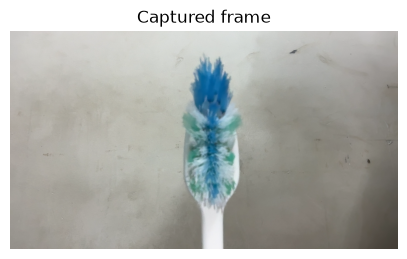

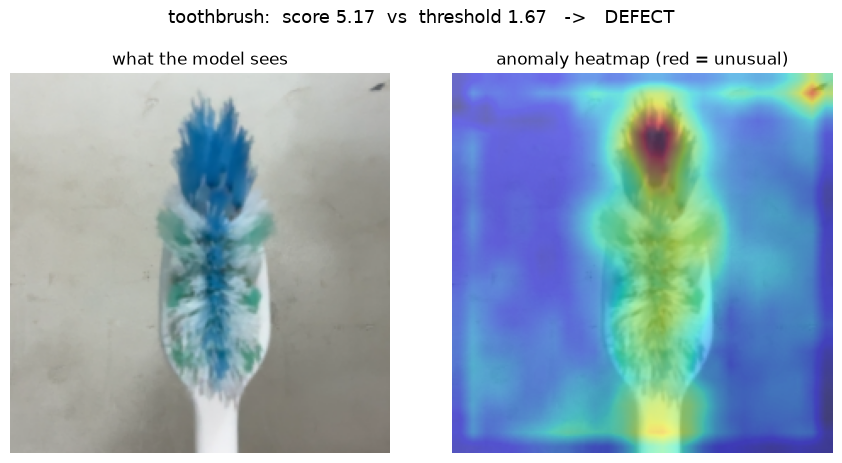

Reminder: absolute score is domain-shifted from a webcam; trust the heatmap most.


In [14]:
PART = "toothbrush"      # <-- change to "bottle" / "screw" / "tile" / "toothbrush"

img = snap()                                             # capture from camera
bank_t, thresh = MODELS[PART]["bank_t"], MODELS[PART]["thresh"]
score, amap = image_score(bank_t, img, return_map=True)
verdict = "DEFECT" if score > thresh else "GOOD"

# show captured image + heatmap side by side
disp = preprocess.transforms[1](preprocess.transforms[0](img.convert("RGB")))   # resize+crop, PIL
up = np.array(Image.fromarray(amap).resize(disp.size, Image.BILINEAR))
fig, ax = plt.subplots(1, 2, figsize=(9, 4.5))
ax[0].imshow(disp); ax[0].set_title("what the model sees"); ax[0].axis("off")
ax[1].imshow(disp); ax[1].imshow(up, cmap="jet", alpha=0.5)
ax[1].set_title("anomaly heatmap (red = unusual)"); ax[1].axis("off")
plt.suptitle(f"{PART}:  score {score:.2f}  vs  threshold {thresh:.2f}   ->   {verdict}",
             fontsize=13, y=1.02)
plt.tight_layout(); plt.show()
print("Reminder: absolute score is domain-shifted from a webcam; trust the heatmap most.")

## 4. (Optional) Score the captured image against ALL 4 models

Handy if you're not sure which model to use, or just exploring. Lower `score / threshold` ratio means
"more consistent with that part's learned normal". Note: PatchCore is a *per-part* anomaly detector,
not a part classifier — this is a rough indicator, not a reliable identifier.

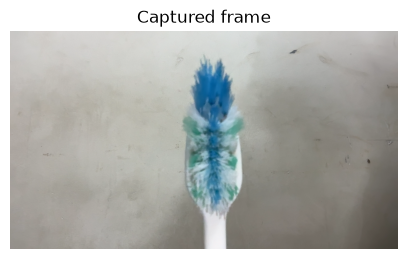

part           score   thresh   ratio   verdict
bottle          5.47     1.75    3.13   DEFECT
screw           5.09     2.30    2.21   DEFECT
tile            5.45     2.17    2.52   DEFECT
toothbrush      5.09     1.67    3.04   DEFECT


In [15]:
img = snap()
print(f"{'part':<12}{'score':>8}{'thresh':>9}{'ratio':>8}   verdict")
for part in PARTS:
    b, th = MODELS[part]["bank_t"], MODELS[part]["thresh"]
    s = image_score(b, img)
    print(f"{part:<12}{s:>8.2f}{th:>9.2f}{s/th:>8.2f}   {'DEFECT' if s > th else 'GOOD'}")

## Troubleshooting

- **Permission prompt / black frame:** macOS must allow the app running Jupyter to use the camera.
  System Settings → Privacy & Security → **Camera** → enable your terminal (e.g. Terminal/iTerm) or
  VS Code, then fully **restart Jupyter**. The very first `cv2.VideoCapture(0)` may also need a couple
  of seconds; just re-run `snap()`.
- **Wrong camera** (e.g. Continuity/iPhone camera grabbed): change `cam_index` in `snap(cam_index=1)`.
- **Everything reads as DEFECT:** expected if the background is busy or the object doesn't fill the
  frame. Use a plain background, get closer, add light. The threshold is dataset-calibrated, so treat
  the **heatmap** as the primary signal.
- **Camera stays locked/green light on:** re-run the cell (each `snap()` releases the camera when it
  finishes); if needed, restart the kernel.
